# 04 - Detecção de Anomalias

Identifica padrões suspeitos nos fundos REAG:

1. **Anomalias de fluxo**: Z-score extremo em captação/resgate
2. **Quedas bruscas de PL**: Reduções > 20% em um dia
3. **Runs**: Sequências de resgates consecutivos
4. **Divergências**: Fluxo vs. performance

In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np          
import matplotlib.pyplot as plt
import seaborn as sns

from src.processors.data_processor import DataProcessor
from src.analyzers.anomaly_detector import AnomalyDetector
from config.settings import Config

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## Carregar Dados Processados

In [2]:
config = Config()
processor = DataProcessor(config)
detector = AnomalyDetector(config)

# Carregar dados REAG processados
data_path = config.PROCESSED_DATA_DIR / 'reag_informe_diario_processed.csv'

if data_path.exists():
    df_reag = pd.read_csv(data_path, sep=';', parse_dates=['DT_COMPTC'])
    print(f"✅ {len(df_reag):,} registros carregados")
else:
    print("⚠️ Execute primeiro o notebook 03_flow_analysis.ipynb")
    df_reag = pd.DataFrame()


✅ 6,225 registros carregados


## 1. Anomalias de Fluxo (Z-Score)

In [3]:
print("🔍 Detectando anomalias de fluxo...")

if df_reag.empty:
    print("⚠️ Dados REAG não carregados. Execute o notebook 03_flow_analysis.ipynb")
    flow_anomalies = pd.DataFrame()
else:
    flow_anomalies = detector.detect_flow_anomalies(df_reag, threshold=3.0)

    print(f"⚠️ {len(flow_anomalies)} anomalias de fluxo detectadas")
    print("Top 10 anomalias:")
    display(flow_anomalies[[
        'CNPJ_FUNDO', 'DT_COMPTC', 'FLUXO_LIQ_DIA', 'Z_SCORE_FLOW'
    ]].head(10))


🔍 Detectando anomalias de fluxo...
⚠️ 52 anomalias de fluxo detectadas
Top 10 anomalias:


,CNPJ_FUNDO,DT_COMPTC,FLUXO_LIQ_DIA,Z_SCORE_FLOW
3017,36935858000195,2025-05-30,2.016122e+07,22.382470
5608,50219185000106,2025-08-01,8.000000e+04,21.503728
4097,42584801000191,2025-01-17,1.647092e+06,18.574253
6042,51305063000197,2025-04-08,1.410000e+05,17.349447
1395,33521273000130,2024-04-02,5.000000e+06,16.955876
1394,33521273000130,2024-04-02,5.000000e+06,16.955876
241,21596695000196,2024-12-18,-1.273100e+07,-15.492067
3983,41801409000194,2024-10-25,-3.277907e+06,-14.351198
1022,32313878000173,2024-12-27,4.794202e+08,13.064724
4346,45616130000191,2025-06-16,1.013000e+09,12.288472


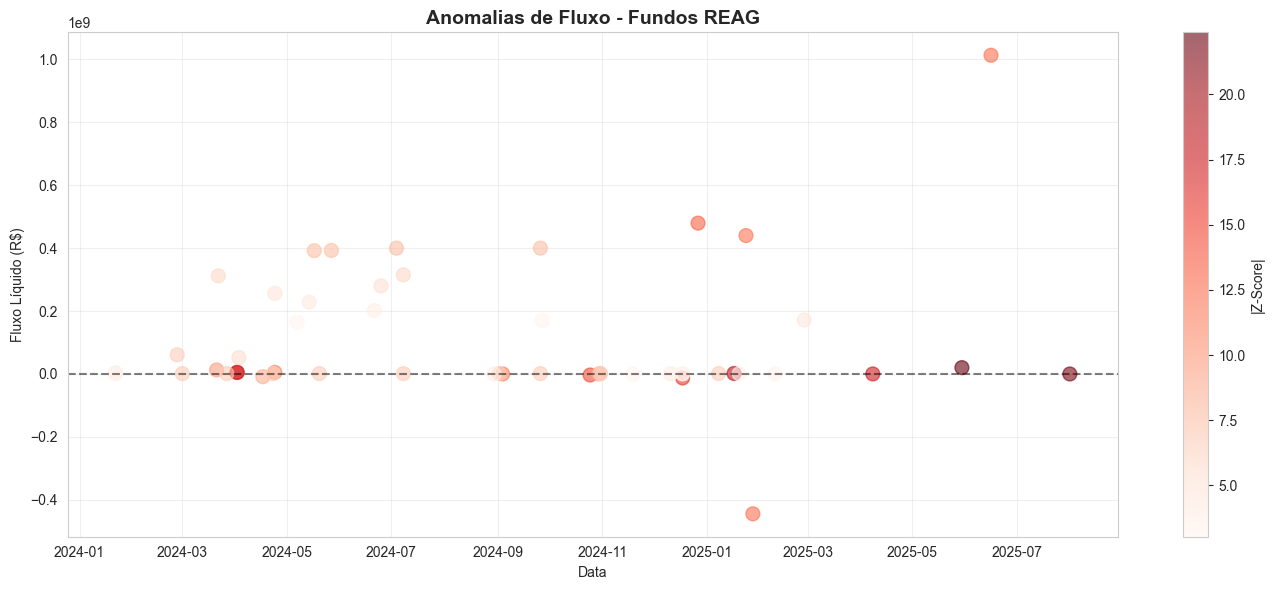

In [4]:
# Visualização
if not flow_anomalies.empty:
    plt.figure(figsize=(14, 6))
    plt.scatter(
        flow_anomalies['DT_COMPTC'], 
        flow_anomalies['FLUXO_LIQ_DIA'],
        c=flow_anomalies['Z_SCORE_FLOW'].abs(),
        cmap='Reds',
        s=100,
        alpha=0.6
    )
    plt.colorbar(label='|Z-Score|')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.title('Anomalias de Fluxo - Fundos REAG', fontsize=14, fontweight='bold')
    plt.xlabel('Data')
    plt.ylabel('Fluxo Líquido (R$)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 2. Quedas Bruscas de PL

In [5]:
print("🔍 Detectando quedas bruscas de PL...")

if df_reag.empty:
    print("⚠️ Dados REAG não carregados. Execute o notebook 03_flow_analysis.ipynb")
    pl_drops = pd.DataFrame()
else:
    pl_drops = detector.detect_pl_drops(df_reag, threshold_pct=20.0)

    print(f"⚠️ {len(pl_drops)} quedas bruscas de PL detectadas")
    print("Top 10 quedas:")
    display(pl_drops[[
        'CNPJ_FUNDO', 'DT_COMPTC', 'VL_PATRIM_LIQ', 'PL_VAR_PCT'
    ]].head(10))


🔍 Detectando quedas bruscas de PL...
⚠️ 56 quedas bruscas de PL detectadas
Top 10 quedas:


,CNPJ_FUNDO,DT_COMPTC,VL_PATRIM_LIQ,PL_VAR_PCT
3013,36935858000195,2025-05-26,-57497192.27,-385.190011
3008,36935858000195,2025-05-19,-56861902.58,-381.828134
3987,42584801000191,2024-08-07,13663.92,-211.752938
4131,42584801000191,2025-03-10,-4062266.80,-206.551126
3009,36935858000195,2025-05-20,20175473.69,-135.481531
3014,36935858000195,2025-05-27,20160432.22,-135.063333
4218,42584801000191,2025-07-15,379147.13,-114.244953
5771,51079517000159,2024-03-28,-31.70,-113.734835
5920,51079517000159,2024-10-31,88.55,-100.143544
4648,48239541000101,2024-04-17,0.00,-100.000000


## 3. Runs (Resgates Consecutivos)

In [6]:
print("🔍 Detectando runs (resgates consecutivos)...")

if df_reag.empty:
    print("⚠️ Dados REAG não carregados. Execute o notebook 03_flow_analysis.ipynb")
    runs = pd.DataFrame()
else:
    runs = detector.detect_runs(df_reag, consecutive_days=5)

    print(f"⚠️ {len(runs)} dias em runs detectados")

    # Agrupar por fundo e run_id para contar sequências
    if not runs.empty:
        run_summary = runs.groupby(['CNPJ_FUNDO', 'RUN_ID']).agg({
            'RUN_LENGTH': 'max',
            'FLUXO_LIQ_DIA': 'sum',
            'DT_COMPTC': ['min', 'max']
        }).reset_index()

        run_summary.columns = ['CNPJ_FUNDO', 'RUN_ID', 'DIAS_CONSECUTIVOS', 'RESGATE_TOTAL', 'DATA_INICIO', 'DATA_FIM']
        run_summary = run_summary.sort_values('DIAS_CONSECUTIVOS', ascending=False)

        print("Top runs por duração:")
        display(run_summary.head(10))


🔍 Detectando runs (resgates consecutivos)...
⚠️ 325 dias em runs detectados
Top runs por duração:


,CNPJ_FUNDO,RUN_ID,DIAS_CONSECUTIVOS,RESGATE_TOTAL,DATA_INICIO,DATA_FIM
6,41751844000151,6,134,-5.721503e+09,2025-06-23,2025-12-31
4,41751844000151,2,125,-5.325399e+09,2024-08-19,2025-02-18
5,41751844000151,4,72,-2.992786e+09,2025-02-27,2025-06-11
0,32313878000173,9,6,-2.034880e+07,2024-01-31,2024-02-01
3,32313878000173,139,6,-2.062942e+06,2025-02-07,2025-02-10
1,32313878000173,11,5,-5.100000e+07,2024-02-15,2024-02-15
2,32313878000173,85,5,-1.753751e+06,2024-09-04,2024-09-04


## 4. Divergências Fluxo vs. Performance

In [7]:
print("🔍 Detectando divergências fluxo vs. performance...")

if df_reag.empty:
    print("⚠️ Dados REAG não carregados. Execute o notebook 03_flow_analysis.ipynb")
    divergences = pd.DataFrame()
else:
    divergences = detector.detect_divergence_flow_performance(df_reag, threshold_z=2.0)

    print(f"⚠️ {len(divergences)} divergências detectadas")
    print("Top 10 divergências:")
    display(divergences[[
        'CNPJ_FUNDO', 'DT_COMPTC', 'RETORNO_DIA', 'FLUXO_LIQ_DIA', 'DIVERGENCE_SCORE'
    ]].head(10))


🔍 Detectando divergências fluxo vs. performance...
⚠️ 10 divergências detectadas
Top 10 divergências:


,CNPJ_FUNDO,DT_COMPTC,RETORNO_DIA,FLUXO_LIQ_DIA,DIVERGENCE_SCORE
4948,48963233000116,2024-12-11,-1.665495,655000.0,30.988733
4663,48357568000190,2024-01-22,-0.000846,3291000.0,16.906227
3398,41751844000151,2024-06-11,-17.392297,0.0,10.633622
1022,32313878000173,2024-12-27,-0.084487,479420200.0,10.118604
4540,46879122000109,2024-03-21,-0.099348,13000000.0,7.989850
850,32313878000173,2024-04-23,0.957446,-22401000.0,4.202044
3399,41751844000151,2024-06-12,-6.575636,0.0,4.042893
2341,36886028000115,2024-12-27,76.822698,0.0,3.494014
4864,48963233000116,2024-10-10,3.565166,0.0,3.343542
3303,41751844000151,2024-01-22,-4.376062,0.0,2.702665


## Relatório Consolidado de Anomalias

In [8]:
print("")
print("="*60)
print("⚠️ RELATÓRIO DE ANOMALIAS - FUNDOS REAG")
print("="*60)

print("")
print(f"1. Anomalias de fluxo (Z-score > 3): {len(flow_anomalies)}")
print(f"2. Quedas bruscas de PL (> 20%): {len(pl_drops)}")
print(f"3. Runs (5+ dias consecutivos): {len(run_summary) if 'run_summary' in locals() else 0}")
print(f"4. Divergências fluxo vs. performance: {len(divergences)}")

total_anomalies = len(flow_anomalies) + len(pl_drops) + len(runs) + len(divergences)
print("")
print(f"🔴 Total de eventos anômalos: {total_anomalies}")



⚠️ RELATÓRIO DE ANOMALIAS - FUNDOS REAG

1. Anomalias de fluxo (Z-score > 3): 52
2. Quedas bruscas de PL (> 20%): 56
3. Runs (5+ dias consecutivos): 7
4. Divergências fluxo vs. performance: 10

🔴 Total de eventos anômalos: 443


## Exportar Anomalias

In [9]:
# Salvar anomalias em arquivos separados
report_dir = config.REPORTS_DIR
report_dir.mkdir(parents=True, exist_ok=True)

if not flow_anomalies.empty:
    flow_anomalies.to_csv(report_dir / 'anomalias_fluxo.csv', index=False)
    print(f"✅ Anomalias de fluxo: {report_dir / 'anomalias_fluxo.csv'}")

if not pl_drops.empty:
    pl_drops.to_csv(report_dir / 'quedas_pl.csv', index=False)
    print(f"✅ Quedas de PL: {report_dir / 'quedas_pl.csv'}")

if not runs.empty and 'run_summary' in locals():
    run_summary.to_csv(report_dir / 'runs_resgate.csv', index=False)
    print(f"✅ Runs: {report_dir / 'runs_resgate.csv'}")

if not divergences.empty:
    divergences.to_csv(report_dir / 'divergencias_flow_performance.csv', index=False)
    print(f"✅ Divergências: {report_dir / 'divergencias_flow_performance.csv'}")

print('')
print(f"📂 Relatórios salvos em: {report_dir}")


✅ Anomalias de fluxo: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports/anomalias_fluxo.csv
✅ Quedas de PL: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports/quedas_pl.csv
✅ Runs: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports/runs_resgate.csv
✅ Divergências: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports/divergencias_flow_performance.csv

📂 Relatórios salvos em: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports


## Resumo

In [10]:
print("\n" + "="*60)
print("✅ DETECÇÃO DE ANOMALIAS CONCLUÍDA")
print("="*60)
print(f"Total de eventos suspeitos: {total_anomalies}")
print(f"Relatórios exportados: {report_dir}")
print("\n✅ Análise completa! Próximos passos: análise manual dos relatórios.")


✅ DETECÇÃO DE ANOMALIAS CONCLUÍDA
Total de eventos suspeitos: 443
Relatórios exportados: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports

✅ Análise completa! Próximos passos: análise manual dos relatórios.


AttributeError: 'int' object has no attribute 'replace'

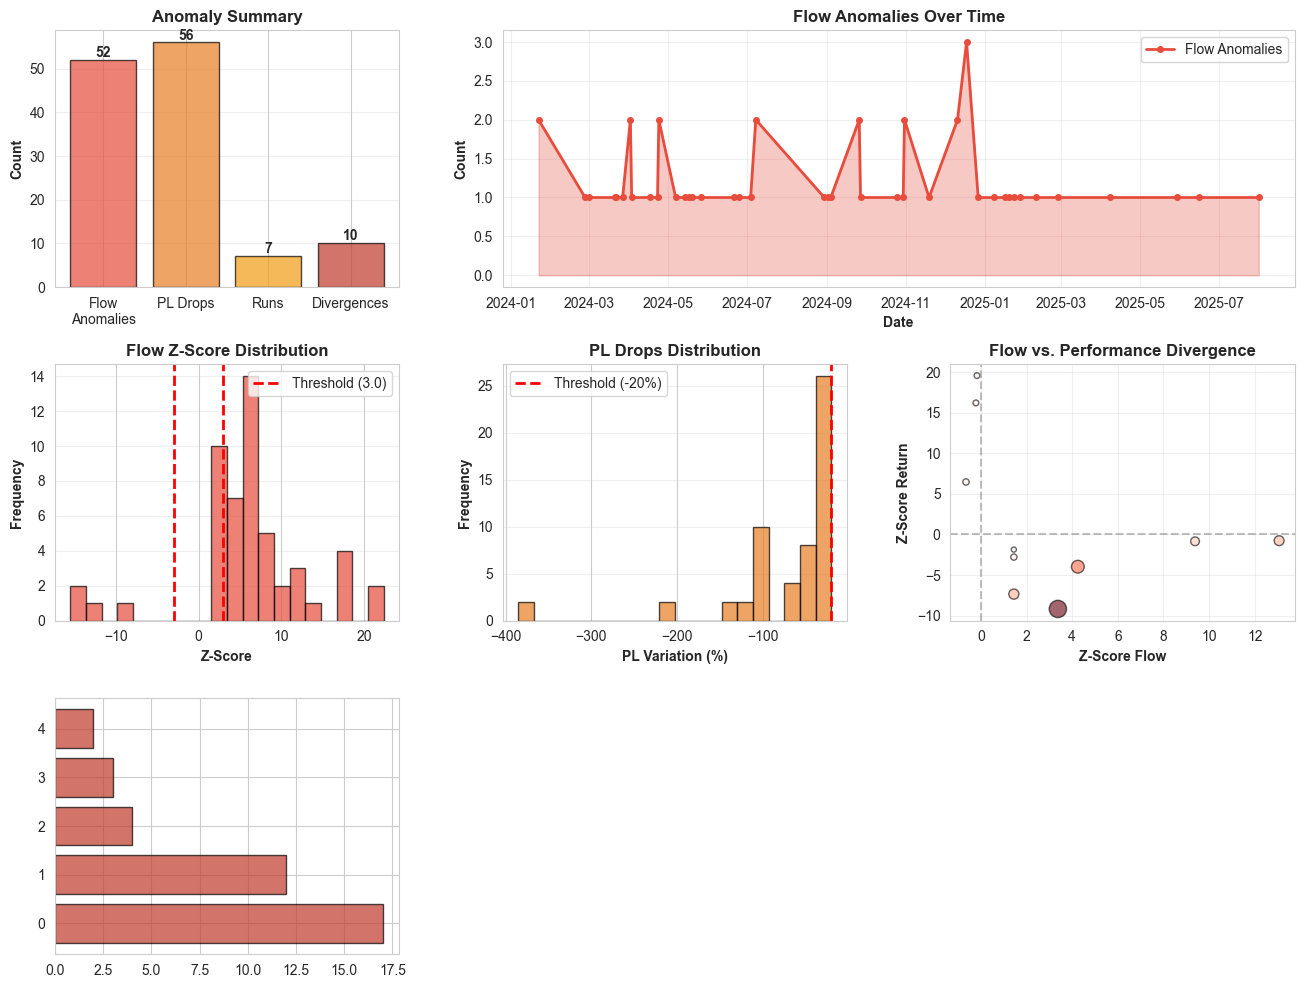

In [11]:
# Create a comprehensive visual dashboard of anomaly findings

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Anomaly Summary (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
anomaly_counts = [len(flow_anomalies), len(pl_drops), len(run_summary), len(divergences)]
anomaly_labels = ['Flow\nAnomalies', 'PL Drops', 'Runs', 'Divergences']
colors = ['#e74c3c', '#e67e22', '#f39c12', '#c0392b']
bars = ax1.bar(anomaly_labels, anomaly_counts, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Anomaly Summary', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 2. Flow Anomalies Over Time (Top Middle & Right)
ax2 = fig.add_subplot(gs[0, 1:])
if not flow_anomalies.empty:
    flow_by_date = flow_anomalies.groupby('DT_COMPTC').size()
    ax2.plot(flow_by_date.index, flow_by_date.values, marker='o', linewidth=2, 
             markersize=4, color='#e74c3c', label='Flow Anomalies')
    ax2.fill_between(flow_by_date.index, flow_by_date.values, alpha=0.3, color='#e74c3c')
    ax2.set_xlabel('Date', fontweight='bold')
    ax2.set_ylabel('Count', fontweight='bold')
    ax2.set_title('Flow Anomalies Over Time', fontweight='bold', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

# 3. Z-Score Distribution (Middle Left)
ax3 = fig.add_subplot(gs[1, 0])
if not flow_anomalies.empty:
    ax3.hist(flow_anomalies['Z_SCORE_FLOW'], bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax3.axvline(3.0, color='red', linestyle='--', linewidth=2, label='Threshold (3.0)')
    ax3.axvline(-3.0, color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Z-Score', fontweight='bold')
    ax3.set_ylabel('Frequency', fontweight='bold')
    ax3.set_title('Flow Z-Score Distribution', fontweight='bold', fontsize=12)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

# 4. PL Drops Distribution (Middle Center)
ax4 = fig.add_subplot(gs[1, 1])
if not pl_drops.empty:
    ax4.hist(pl_drops['PL_VAR_PCT'], bins=20, color='#e67e22', alpha=0.7, edgecolor='black')
    ax4.axvline(-20.0, color='red', linestyle='--', linewidth=2, label='Threshold (-20%)')
    ax4.set_xlabel('PL Variation (%)', fontweight='bold')
    ax4.set_ylabel('Frequency', fontweight='bold')
    ax4.set_title('PL Drops Distribution', fontweight='bold', fontsize=12)
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

# 5. Divergence Scores (Middle Right)
ax5 = fig.add_subplot(gs[1, 2])
if not divergences.empty:
    ax5.scatter(divergences['Z_FLOW'], divergences['Z_RETORNO'], 
               s=divergences['DIVERGENCE_SCORE']*5, alpha=0.6, 
               c=divergences['DIVERGENCE_SCORE'], cmap='Reds', edgecolor='black')
    ax5.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax5.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax5.set_xlabel('Z-Score Flow', fontweight='bold')
    ax5.set_ylabel('Z-Score Return', fontweight='bold')
    ax5.set_title('Flow vs. Performance Divergence', fontweight='bold', fontsize=12)
    ax5.grid(True, alpha=0.3)

# 6. Top Anomalous Funds (Bottom Left)
ax6 = fig.add_subplot(gs[2, 0])
if not flow_anomalies.empty:
    top_funds = flow_anomalies['CNPJ_FUNDO'].value_counts().head(5)
    ax6.barh(range(len(top_funds)), top_funds.values, color='#c0392b', alpha=0.7, edgecolor='black')
    ax6.set_yticks(range(len(top_funds)))
    ax6.set_yticklabels([f.replace('/', '\n') for f in top_funds.index], fontsize=8)
    ax6.set_xlabel('Count', fontweight='bold')
    ax6.set_title('Top 5 Anomalous Funds', fontweight='bold', fontsize=12)
    ax6.grid(axis='x', alpha=0.3)

# 7. Runs Summary (Bottom Center)
ax7 = fig.add_subplot(gs[2, 1])
if not run_summary.empty:
    run_summary_sorted = run_summary.nlargest(5, 'DIAS_CONSECUTIVOS')
    ax7.barh(range(len(run_summary_sorted)), run_summary_sorted['DIAS_CONSECUTIVOS'].values, 
            color='#f39c12', alpha=0.7, edgecolor='black')
    ax7.set_yticks(range(len(run_summary_sorted)))
    ax7.set_yticklabels([f.replace('/', '\n') for f in run_summary_sorted['CNPJ_FUNDO']], fontsize=8)
    ax7.set_xlabel('Days', fontweight='bold')
    ax7.set_title('Top 5 Longest Runs', fontweight='bold', fontsize=12)
    ax7.grid(axis='x', alpha=0.3)

# 8. Total Anomalies Summary (Bottom Right)
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
summary_text = f"""
📊 ANOMALY DASHBOARD SUMMARY

Total Events: {total_anomalies}

Flow Anomalies: {len(flow_anomalies)}
PL Drops: {len(pl_drops)}
Consecutive Runs: {len(run_summary)}
Divergences: {len(divergences)}

⚠️ Risk Level: HIGH
All anomalies exported to:
{report_dir}
"""
ax8.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('🔍 REAG Fraud Investigation - Anomaly Detection Dashboard', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("\n✅ Dashboard generated successfully!")